### **Load Dependencies**

In [1]:
import time
from prompts import *
from typing import List, TypedDict, Literal
from pydantic import BaseModel, Field
from IPython.display import Markdown, display, Image

from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate

from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv

load_dotenv()

True

- **Load Docs**

In [2]:
docs = (
    PyPDFLoader("./docs/Company_Policies.pdf").load()
    + PyPDFLoader("./docs/Company_Profile.pdf").load()
    + PyPDFLoader("./docs/Product_and_Pricing.pdf").load()
)

- **Split Docs into Chunks**

In [3]:
chunks = RecursiveCharacterTextSplitter(
    chunk_size=600, chunk_overlap=150
).split_documents(docs)

- **Embed Chunks and Create Retriever**

In [4]:
embeddings = OpenAIEmbeddings(model="text-embedding-3-large")
vector_store = FAISS.from_documents(chunks, embeddings)
retriever = vector_store.as_retriever(search_kwargs={"k": 4})

- **Create LLM**

In [5]:
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

### **Graph Building**

- **Graph State**

In [57]:
class State(TypedDict):
    question: str
    need_retrieval: Literal[True, False]

    docs: List[Document]
    relevant_docs: List[Document]

    context: str
    answer: str

#### **Decide Retrieval Node**
- Decide whether retrieval is necessary for answering the question

In [58]:
class RetrieveDecision(BaseModel):
    should_retrieve: bool = Field(
        ...,
        description="Whether the agent should perform retrieval to answer the question."
    )

In [59]:
def decide_retrieval(state: State) -> dict:
    """ This function uses the LLM to decide whether retrieval is necessary to answer the question."""

    should_retrieve_llm = llm.with_structured_output(RetrieveDecision)
    decision: RetrieveDecision = should_retrieve_llm.invoke(
        decide_retrieval_prompt.format_prompt(question=state["question"])
    )
    
    return { "need_retrieval" : decision.should_retrieve }

In [60]:
decision = decide_retrieval({"question": "What is the company policy?"})
decision

{'need_retrieval': True}

#### **Generate Answer**
- Generate a direct answer to the question.

In [61]:
def generate_direct(state: State) -> dict:
    """ This function uses the LLM to generate a direct answer to the question."""

    answer = llm.invoke(
        direct_generation_prompt.format_prompt(question=state["question"])
    )
    return {"answer": answer.content}

In [62]:
answer = generate_direct({ "question" : "What is Machine Learning?" })['answer']
# display(Markdown(answer))

#### **Retrieve Docs**
- Retrieve docs using the retriever

In [63]:
def retrieve(state: State) -> dict:
    """ This function performs retrieval using the retriever and returns the retrieved documents."""
    retrieved_docs = retriever.invoke(state["question"])
    return {"docs": retrieved_docs}

In [64]:
retrieved_docs = retrieve({"question": "Who is the CEO of NexaAI"})

In [65]:
display(Markdown(retrieved_docs['docs'][0].page_content))

Founder
Aarav Mehta founded NexaAI after over 10 years of experience in enterprise data platforms and
cloud infrastructure.
He previously worked with global consulting firms where he led multiple large-scale digital
transformation projects.
Leadership Team
The leadership team brings experience across AI engineering, product management, and business
operations.

Aarav Mehta – CEO & Founder

Riya Kapoor – CTO (Distributed systems & AI platforms)

Kunal Sharma – Head of Product

Neha Verma – Head of Operations & HR

Siddharth Rao – Head of Sales & Partnerships

#### **Decide Relevance**
- Decide whether a retrieved document is relevant to answer the question

In [66]:
class RelevanceDecision(BaseModel):
    is_relevant: bool = Field(
        ...,
        description="True if the document helps answer the question, else False."
    )

def decide_relevance(state: State) -> dict:
    """ This function uses the LLM to decide whether a retrieved document is relevant to answer the question."""

    relevance_llm = llm.with_structured_output(RelevanceDecision)
    
    relevant_docs: List[Document] = []
    irrelevant_docs: List[Document] = []

    for doc in state["docs"]:
        decision: RelevanceDecision = relevance_llm.invoke(
            is_relevant_prompt.format_messages(
                question=state["question"],
                document=doc.page_content
            )
        )

        if decision.is_relevant:
            relevant_docs.append(doc)
        else:
            irrelevant_docs.append(doc)

    return {"relevant_docs": relevant_docs, "irrelevant_docs": irrelevant_docs}

In [67]:
relevant_docs = decide_relevance({
    "question": "Who is the CEO of NexaAI",
    "docs": retrieved_docs["docs"]
})

In [68]:
relevant_docs['relevant_docs']

[Document(id='be97285e-fe00-4c0f-97a3-1191e0616db4', metadata={'producer': 'ReportLab PDF Library - www.reportlab.com', 'creator': '(unspecified)', 'creationdate': '2026-02-14T13:07:17+00:00', 'author': '(anonymous)', 'keywords': '', 'moddate': '2026-02-14T13:07:17+00:00', 'subject': '(unspecified)', 'title': '(anonymous)', 'trapped': '/False', 'source': './docs/Company_Profile.pdf', 'total_pages': 2, 'page': 1, 'page_label': '2'}, page_content='Founder\nAarav Mehta founded NexaAI after over 10 years of experience in enterprise data platforms and\ncloud infrastructure.\nHe previously worked with global consulting firms where he led multiple large-scale digital\ntransformation projects.\nLeadership Team\nThe leadership team brings experience across AI engineering, product management, and business\noperations.\n\x7f\nAarav Mehta – CEO & Founder\n\x7f\nRiya Kapoor – CTO (Distributed systems & AI platforms)\n\x7f\nKunal Sharma – Head of Product\n\x7f\nNeha Verma – Head of Operations & HR\n

In [69]:
len(retrieved_docs['docs'])

4

In [70]:
len(relevant_docs['irrelevant_docs'])

3

#### **Generate Answer From Context**
- Generate an answer to the question using the retrieved context

In [71]:
def generate_from_context(state: State) -> dict:
    """ This function uses the LLM to generate an answer to the question using the retrieved context."""

    context = "\n\n---\n\n".join(
        [doc.page_content for doc in state.get("relevant_docs", [])]
    ).strip()

    if not context:
        return { "answer" : "No relevant document found.", "context": "" }

    output = llm.invoke(
        rag_generation_prompt.format_messages(
            question=state["question"],
            context=context
        )
    )
    return {"answer": output.content, "context": context}

In [72]:
answer = generate_from_context({
    "question": "Who is the CEO of NexaAI",
    "relevant_docs": relevant_docs["relevant_docs"]
})

In [73]:
display(Markdown(answer['answer']))

The CEO of NexaAI is Aarav Mehta.

#### **No Relevant Docs**
- Generate an answer when no relevant documents are found

In [74]:
def no_relevant_docs(state: State) -> dict:
    """ This function generates an answer when no relevant documents are found."""

    return { "answer" : "No relevant document found.", "context": "" }

#### **Router**
- route_after_decide: This function routes the state to the appropriate function based on whether retrieval is needed or not.

In [75]:
def router_after_decide(state: State) -> str:
    """ This function routes the state to the appropriate function based on whether retrieval is needed or not."""
    
    if state["need_retrieval"]:
        return "need_retrieval"
    else:
        return "generate_direct"

- route_after_relevance: This function routes the state to the appropriate function based on whether relevant documents are found or not.

In [76]:
def route_after_relevance(state: State) -> str:
    """ This function routes the state to the appropriate function based on whether relevant documents are found or not."""
    
    if state.get("relevant_docs") and len(state["relevant_docs"]) > 0:
        return "context"
    else:
        return "irrelevant"

#### **Graph Building**

In [77]:
# State graph construction
builder = StateGraph(State)

# Adding nodes
builder.add_node("decide_retrieval", decide_retrieval)
builder.add_node("retrieve", retrieve)
builder.add_node("generate_answer", generate_direct)
builder.add_node("decide_relevance", decide_relevance)
builder.add_node("generate_from_context", generate_from_context)
builder.add_node("no_relevant_docs", no_relevant_docs)

# Adding edges
builder.add_edge(START, "decide_retrieval")

builder.add_conditional_edges(
    "decide_retrieval", router_after_decide,
    {
        "need_retrieval": "retrieve",
        "generate_direct": "generate_answer"
    }
)

builder.add_conditional_edges(
    "decide_relevance", route_after_relevance,
    {
        "context": "generate_from_context",
        "irrelevant": "no_relevant_docs"
    }
)

builder.add_edge("retrieve", "decide_relevance")
builder.add_edge("generate_answer", END)
builder.add_edge("generate_from_context", END)
builder.add_edge("no_relevant_docs", END)

# Compile the graph
rag = builder.compile()

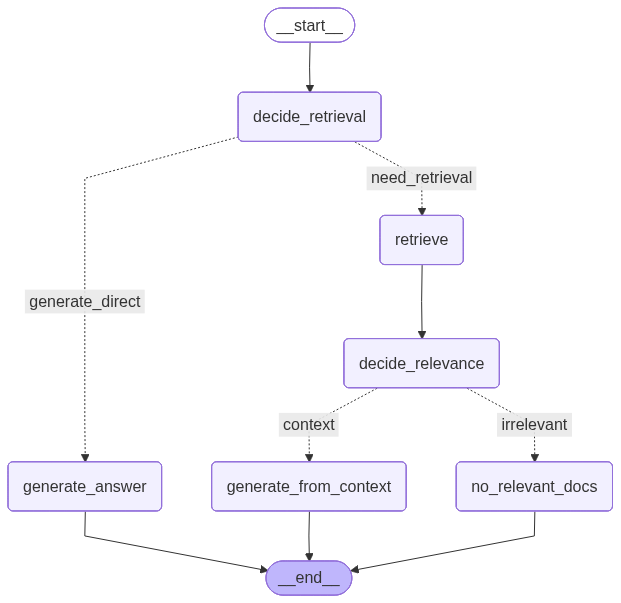

In [78]:
display(Image(rag.get_graph().draw_mermaid_png()))

#### **Test Graph**

In [79]:
result = rag.invoke(
    {
        "question": "What is the refund policy of NexaAI",
        "docs": [],
        "relevant_docs": [],
        "context": "",
        "answer": "",
    }
)

print(result["answer"])

No relevant document found.


In [80]:
result.keys()

dict_keys(['question', 'need_retrieval', 'docs', 'relevant_docs', 'context', 'answer'])

In [81]:
result['need_retrieval']

True

In [82]:
for doc in result['docs']:
    display(Markdown(f"**Source:** {doc.metadata['source']}"))
    display(Markdown(doc.page_content))
    display(Markdown("*"*150))

**Source:** ./docs/Company_Policies.pdf

NexaAI Solutions – Company Policies
HR Policies
NexaAI is committed to maintaining a fair, inclusive, and performance-driven workplace.
All employment decisions are made without discrimination.

Equal opportunity employer

Bi-annual performance reviews

Clear career progression framework

Strict anti-harassment policy
Leave Policy
Employees are encouraged to maintain a healthy work-life balance.

Annual Leave: 18 working days per year

Sick Leave: 10 working days per year

Casual Leave: 6 working days per year

Maternity Leave: As per statutory norms


******************************************************************************************************************************************************

**Source:** ./docs/Product_and_Pricing.pdf

NexaAI Solutions – Products & Pricing
Product Portfolio Overview
NexaAI offers a modular suite of enterprise AI products designed to help organizations manage
knowledge, analyze business data, automate customer interactions, and enforce AI governance.
Each product can be used independently or deployed as part of an integrated AI platform.
NexaChat – Internal Knowledge Assistant
NexaChat is an AI-powered internal assistant that allows employees to query company documents,
policies, reports, and knowledge bases using natural language.

...

NexaAI Solutions – Company Profile
Company Overview
NexaAI Solutions Pvt. Ltd. is a business-focused artificial intelligence company founded in 2021.
The company specializes in building enterprise-ready AI systems for knowledge management,
analytics, and automation.
NexaAI primarily serves mid-sized and large organizations across technology, finance, healthcare,
and education sectors.

Founded: 2021

Headquarters: Bengaluru, India

Employees: 85+

Operating Regions: India, Southeast Asia, Europe
Vision

******************************************************************************************************************************************************

**Source:** ./docs/Product_and_Pricing.pdf

Pricing & Plans
NexaAI pricing is based on the number of active users and selected product modules. All plans
include standard security updates and product enhancements.
Starter Plan
Designed for small teams and early-stage adoption.

Price: ■2,499 per user per month

Access to NexaChat core features

Up to 5,000 queries per month

Email-based customer support

Shared cloud infrastructure
Growth Plan
Best suited for growing teams requiring deeper insights and integrations.

Price: ■5,999 per user per month

Access to NexaChat, NexaInsight, and NexaSupport


******************************************************************************************************************************************************

In [83]:
for doc in result['relevant_docs']:
    display(Markdown(f"**Source:** {doc.metadata['source']}"))
    display(Markdown(doc.page_content))
    display(Markdown("*"*150))